In [1]:
import pandas as pd
import numpy as np
import warnings 
import holidays
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

In [2]:
df2024 = pd.read_csv('../../Data/Zero/2024_data.csv')
df2025 = pd.read_csv('../../Data/Zero/2025_data.csv')

df = pd.concat([df2024,df2025],axis=0)
kr = holidays.KR()

In [3]:
# 1. 시작 대여소 기준으로만 필터링 (순수 대여량 예측 목적)
target_station = ['ST-1035', 'ST-454', 'ST-471']
df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])
df['year'] = df['기준_날짜'].dt.year
df['weekday'] = df['기준_날짜'].dt.dayofweek
df['day_type'] = np.where(df['weekday'] < 5, 0, 1)
df = df[(df['전체_이용_분'] >= 5) & (df['전체_이용_거리'] >= 5)]
df['datetime'] = pd.to_datetime(df['기준_날짜']) + pd.to_timedelta(df['시간대'], unit='h')
df = df[df['시작_대여소_ID'].isin(target_station)].copy()
df_hourly = df.groupby(['시작_대여소_ID', 'datetime','year']).agg({
    '전체_건수': 'sum',
    '온도': 'mean',
    '습도': 'mean',
    '불쾌지수': 'mean',
    '강수량': 'mean',
    '적설량': 'mean'
}).reset_index()


In [4]:
df

,기준_날짜,시간대,집계_기준,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,불쾌지수,강수량,적설량,year,weekday,day_type,datetime
0,2024-01-01,0,출발시간,ST-454,ST-1331,1.0,6900,11170.0,-2.7,92,28.49784,0.0,0.0,2024,0,0,2024-01-01 00:00:00
1,2024-01-01,0,출발시간,ST-454,ST-349,1.0,1560,4473.0,-2.7,92,28.49784,0.0,0.0,2024,0,0,2024-01-01 00:00:00
2,2024-01-01,0,출발시간,ST-454,ST-1025,1.0,720,1960.0,-2.7,92,28.49784,0.0,0.0,2024,0,0,2024-01-01 00:00:00
4,2024-01-01,0,출발시간,ST-1035,ST-3058,1.0,840,1821.0,-2.7,92,28.49784,0.0,0.0,2024,0,0,2024-01-01 00:00:00
5,2024-01-01,0,출발시간,ST-1035,ST-3058,1.0,840,1821.0,-2.7,92,28.49784,0.0,0.0,2024,0,0,2024-01-01 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160159,2025-12-31,22,출발시간,ST-454,ST-1038,1.0,3060,1511.0,-8.5,51,27.83035,0.0,0.0,2025,2,0,2025-12-31 22:00:00
160161,2025-12-31,22,출발시간,ST-1035,ST-1035,1.0,780,1930.0,-8.5,51,27.83035,0.0,0.0,2025,2,0,2025-12-31 22:00:00
160162,2025-12-31,22,출발시간,ST-454,ST-1038,1.0,3060,1511.0,-8.5,51,27.83035,0.0,0.0,2025,2,0,2025-12-31 22:00:00
160163,2025-12-31,23,출발시간,ST-454,ST-479,1.0,480,1390.0,-8.8,51,27.43588,0.0,0.0,2025,2,0,2025-12-31 23:00:00


In [5]:
# 1. 시간대와 요일 정보 다시 추출
df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['weekday'] = df_hourly['datetime'].dt.dayofweek
df_hourly['is_weekend'] = np.where(df_hourly['weekday'] < 5, 0, 1)
df_hourly['is_holiday'] = df_hourly['datetime'].dt.date.isin(kr)

# 2. 대여소 ID를 숫자로 변환 (HGB가 대여소별 특징을 알게 함)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_hourly['station_idx'] = le.fit_transform(df_hourly['시작_대여소_ID'])
df_hourly = df_hourly.sort_values(['시작_대여소_ID', 'datetime'])

df_hourly['lag_1h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(1)
df_hourly['lag_2h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(2)

df_hourly['lag_24h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(24)

df_hourly['rolling_3h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].transform(lambda x: x.shift(1).rolling(3).mean())

df_hourly = df_hourly.dropna()

df_hourly['hour_sin'] = np.sin(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['hour_cos'] = np.cos(2 * np.pi * df_hourly['hour'] / 24)


In [6]:
all_stations = df_hourly['시작_대여소_ID'].unique()
all_times = pd.date_range(start=df_hourly['datetime'].min(), 
                          end=df_hourly['datetime'].max(), 
                          freq='h')

multi_idx = pd.MultiIndex.from_product([all_stations, all_times], 
                                       names=['시작_대여소_ID', 'datetime'])
df_full = pd.DataFrame(index=multi_idx).reset_index()

df_hourly = pd.merge(df_full, df_hourly, on=['시작_대여소_ID', 'datetime'], how='left')

df_hourly['전체_건수'] = df_hourly['전체_건수'].fillna(0) # 대여 없는 시간은 0건
df_hourly['year'] = df_hourly['datetime'].dt.year
df_hourly[['온도', '습도', '불쾌지수', '강수량', '적설량']] = \
    df_hourly.groupby('시작_대여소_ID')[['온도', '습도', '불쾌지수', '강수량', '적설량']].ffill()


df_hourly = pd.get_dummies(df_hourly, columns=['시작_대여소_ID'], prefix='st')

# 2. 새로운 피처 리스트 생성 (기 station_idx 제외하고 새로 생긴 st_... 컬럼들 추가)
station_cols = [col for col in df_hourly.columns if col.startswith('st_')]
target = '전체_건수'
features = [
    # 'hour',
      'weekday', 
    # 'is_weekend', 'is_holiday',
    '온도', '습도',
      # '불쾌지수',
        '강수량', '적설량',
    'lag_1h', 
    # 'lag_2h',
    #   'rolling_3h',
      'lag_24h',
    'hour_sin',
    #   'hour_cos'
] 


==============================

In [7]:
train = df_hourly[df_hourly['year'] == 2024]
test  = df_hourly[df_hourly['year'] == 2025]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

x_input, x_valid, y_input, y_valid = train_test_split(
    X_train, y_train, random_state=42, test_size=0.2
)

hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=600,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

scores = cross_validate(
    hgb,
    X_train,
    np.log1p(y_train),
    n_jobs=-1,
    return_train_score=True
)

# log 변환 학습
hgb.fit(x_input, np.log1p(y_input))

# score는 log scale끼리 비교해야 의미 있음
print("train score(log):", hgb.score(x_input, np.log1p(y_input)))
print("valid score(log):", hgb.score(x_valid, np.log1p(y_valid)))

print("All Train score(log):", hgb.score(X_train, np.log1p(y_train)))
print("Test score(log):", hgb.score(X_test, np.log1p(y_test)))
# 원래 값으로 복원해서 평가
pred_input = np.expm1(hgb.predict(x_input))
pred_valid = np.expm1(hgb.predict(x_valid))
pred_train = np.expm1(hgb.predict(X_train))
pred_test = np.expm1(hgb.predict(X_test))

print('========================')

print("Input MAE:", mean_absolute_error(y_input, pred_input))
print("Input RMSE:", np.sqrt(mean_squared_error(y_input, pred_input)))
print("Input R2:", r2_score(y_input, pred_input))

print('========================')

print("VALID MAE:", mean_absolute_error(y_valid, pred_valid))
print("VALID RMSE:", np.sqrt(mean_squared_error(y_valid, pred_valid)))
print("VALID R2:", r2_score(y_valid, pred_valid))

print('========================')
print("Train MAE:", mean_absolute_error(y_train, pred_train))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, pred_train)))
print("Train R2:", r2_score(y_train, pred_train))

print('========================')
print("TEST MAE:", mean_absolute_error(y_test, pred_test))
print("TEST RMSE:", np.sqrt(mean_squared_error(y_test, pred_test)))
print("TEST R2:", r2_score(y_test, pred_test))

train score(log): 0.8647569051045176
valid score(log): 0.846577531386621
All Train score(log): 0.8611382729020718
Test score(log): 0.855071351163627
Input MAE: 1.6099650112652684
Input RMSE: 3.021292180229167
Input R2: 0.6732955486393639
VALID MAE: 1.694385915719238
VALID RMSE: 3.1237965754620443
VALID R2: 0.6336460319697794
Train MAE: 1.6268517643956861
Train RMSE: 3.0420725422231243
Train R2: 0.6656665763719121
TEST MAE: 1.4101344926180446
TEST RMSE: 2.7404118248375164
TEST R2: 0.6210790439716849


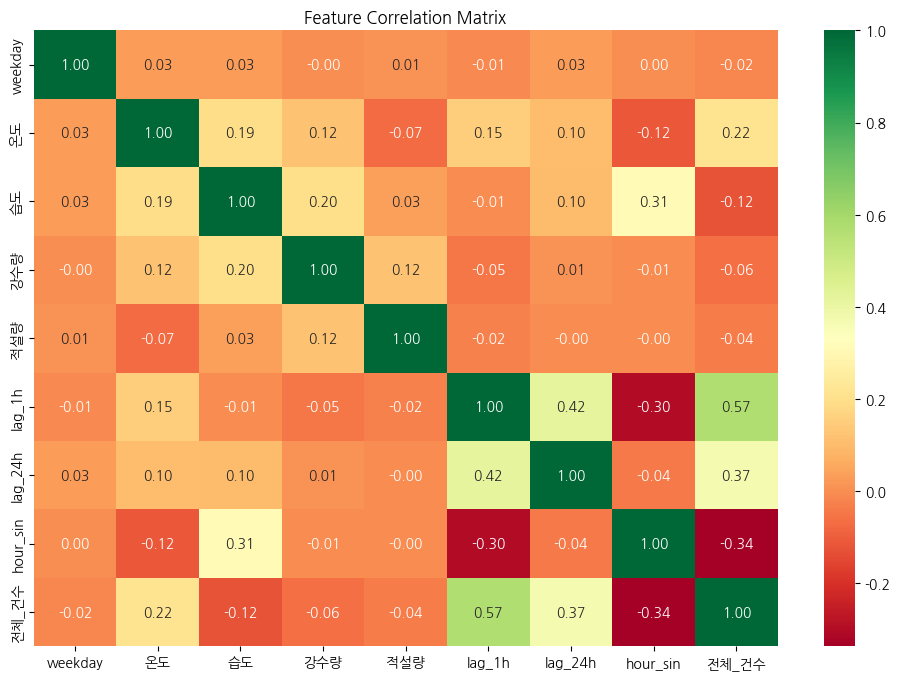

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 분석에 사용할 변수들만 추출
corr_df = df_hourly[features + [target]]

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [9]:
corr_df

,weekday,온도,습도,강수량,적설량,lag_1h,lag_24h,hour_sin,전체_건수
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...
52531,2.0,-7.2,43.0,0.0,0.0,1.0,2.0,-0.965926,1.0
52532,2.0,-7.9,45.0,0.0,0.0,1.0,2.0,-0.866025,2.0
52533,NaN,-7.9,45.0,0.0,0.0,NaN,NaN,NaN,0.0
52534,NaN,-7.9,45.0,0.0,0.0,NaN,NaN,NaN,0.0


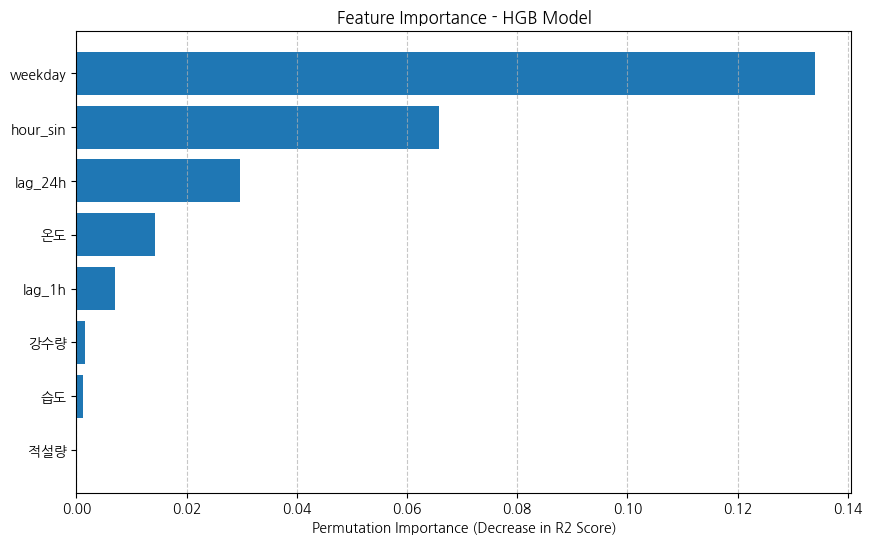

In [10]:
from sklearn.inspection import permutation_importance

# 테스트 데이터셋을 기준으로 측정합니다.
result = permutation_importance(hgb, X_test, y_test, n_repeats=10, random_state=42)

# 시각화를 위해 정렬
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(np.array(features)[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance (Decrease in R2 Score)")
plt.title("Feature Importance - HGB Model")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()